# Hotel Booking Demand Analysis
## Explorative Data Analysis
* **Goal:** Explore booking patterns and cancellation rates 

In [213]:
# Import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'hotel_bookings.csv'

# Safe data loading to catch potential file path or access issues
try:
    df = pd.read_csv(file_path)
    print('Load successfully')
except FileNotFoundError:
    print('Error: File not found')


Load successfully


In [214]:
# First inspection of the data set
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [215]:
# Inspect the statistic metrics
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [216]:
# Checking for rows and columns
print(f' Rows: {df.shape[0]} -- Columns {df.shape[1]}')

 Rows: 119390 -- Columns 32


In [217]:
# Checking on missing values
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [218]:
# Checking for duplicates
df.duplicated().sum()

df[df.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,...,No Deposit,9.0,NaN,0,Transient,126.00,0,2,Check-Out,2017-09-03
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


**Note:** Since the data is fully anonymized and lacks unique identifiers (like a Booking ID), it is impossible to verify if identical rows are system errors or legitimate duplicate bookings. In the hotel industry, it is very common for companies or travel agents to book multiple identical rooms for events, conferences, or tour groups. Therefore, to avoid losing real business volume, I will keep these rows for the analysis.

# Explorative Data Analysis

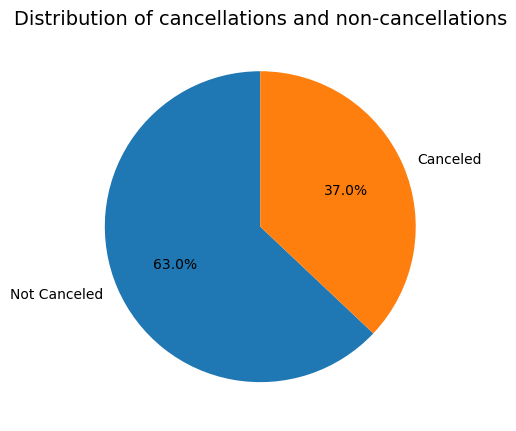

In [219]:
# Question: What is the breakdown of cancellations and non-cancellations
# Visualize the distribution of cancellation and non-cancellation
cancellation_counts = df['is_canceled'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(cancellation_counts, labels=['Not Canceled', 'Canceled'], autopct='%1.1f%%', startangle=90)

plt.title('Distribution of cancellations and non-cancellations', fontsize=14)
plt.tight_layout()
plt.show()

### Analysis: Breakdown of Cancellations
The chart reveals that while **63.0%** of the bookings are successfully completed (not canceled), a substantial **37.0%** of all bookings end up being canceled. 

In the hospitality industry, a cancellation rate this high severely impacts revenue stability and room capacity planning. This finding strongly demands further investigations to identify the driving factors behind these cancellations (e.g., specific customer types, deposit policies, or lead times).

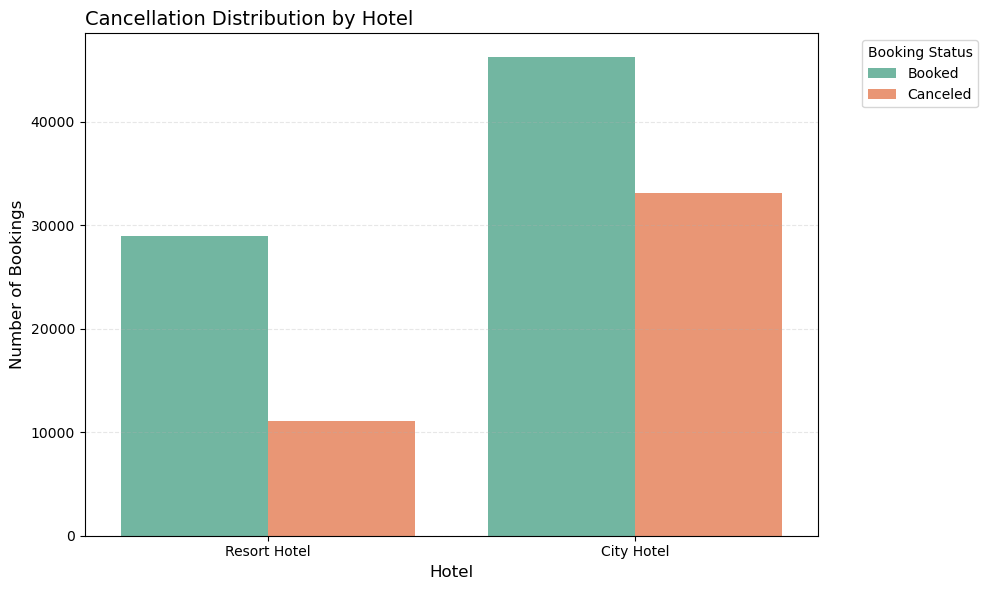

--Realtiv Cancellation Rate---
City Hotel: 41.73%
Resort Hotel: 27.76%


In [ ]:
# Questions: Does the City Hotel or Resort Hotel has more cancellations? 
hotel_df = df.groupby('hotel')['is_canceled'].value_counts()

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='hotel', hue='is_canceled', palette='Set2')
plt.title('Cancellation Distribution by Hotel', fontsize=14, loc='left')
plt.xlabel('Hotel', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='Status', labels=['Booked', 'Canceled'])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


print('--Realtiv Cancellation Rate---')
city_hotel = round(33102 / (46228 + 33102) * 100, 2)
resort_hotel = round(11122 / (28938 + 11122) * 100, 2)
print(f'City Hotel: {city_hotel}%')
print(f'Resort Hotel: {resort_hotel}%')

### Analysis of Cancellation Distribution by Hotel
* **City Hotel:** The chart illustrates that the City Hotel experiences a significantly higher volume of cancellations in absolute numbers. When looking at the ratio, the cancellation rate reaches roughly **41.73%** (approx. 33,000 cancellations out of 79,000 total bookings). This is exceptionally high and requires a deep-dive evaluation into the underlying reasons.
* **Resort Hotel:** In contrast, the Resort Hotel shows a healthier balance between confirmed and canceled bookings. With a cancellation rate of about **27.76%** (approx. 11,000 cancellations out of 40,000 total bookings), it proves to be more stable, which is typical for leisure travel where trips are planned further in advance and less likely to be dropped.

**Research Questions:** <br>
* is there a context between lead time and cancellation - does guest cancel their bookings more often, when they booked it over 4 or 5 months in advance?
* is there a higher cancellation rate, when bookings involed children? Due to circumstances with kids there is may a higher cancellation rate
* is there a pattern for special months or days for cancellations? 
* are the restricted rates cancelled in advance? Or does the restricted rates require a deposit and due to that factor the cancellation rate is less? 
* what are the typically high and low seasons for each hotel?
* what are the high and low days for each hotel? 
* how much no shows does the hotels have are no show costs covered from deposits?

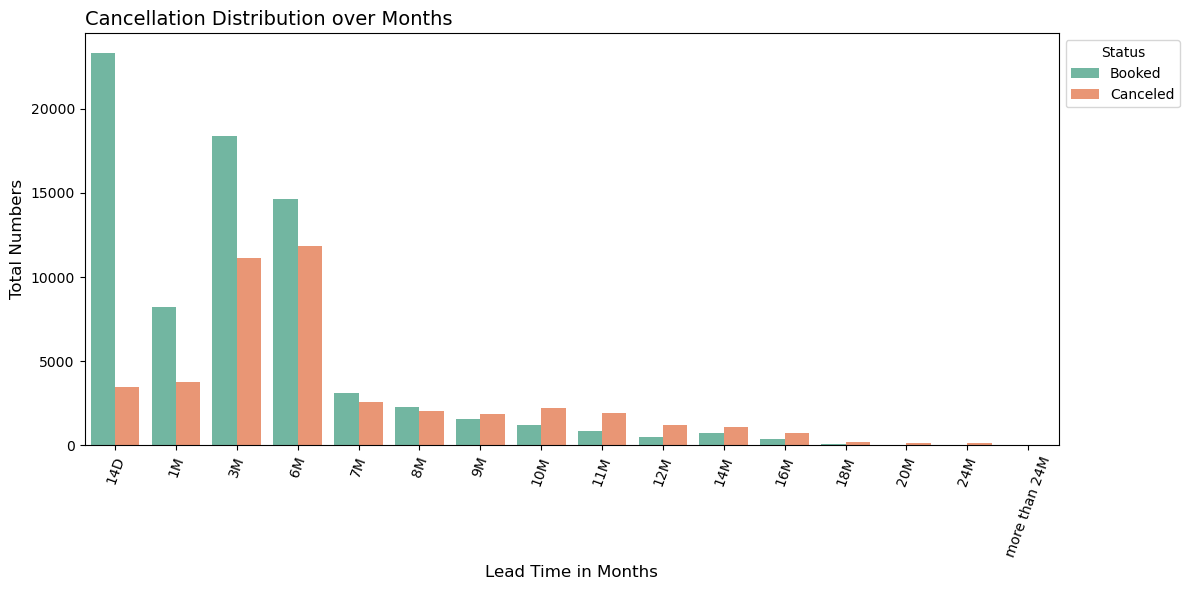

In [246]:
# Question: Is there a context between lead time and cancellation
# Analys with pd.cut to group the lead time days into months for better overview
month_bins = [-1, 14, 30, 90, 180, 210, 240, 270, 300, 330, 360, 420, 480, 540, 600, 660, df['lead_time'].max()]
month_labels = ['14D', '1M', '3M', '6M', '7M', '8M', '9M', '10M', '11M', '12M', '14M', '16M', '18M', '20M', '24M', 'more than 24M']

df['lead_time_group'] = pd.cut(df['lead_time'], bins=month_bins, labels=month_labels)

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='lead_time_group', hue='is_canceled', palette='Set2')
plt.title('Cancellation Distribution over Months', fontsize=14, loc='left')
plt.xlabel('Lead Time in Months', fontsize=12)
plt.ylabel('Total Numbers', fontsize=12)
plt.legend(bbox_to_anchor=(1,1), loc='upper left', title='Status', labels=['Booked', 'Canceled'])
plt.xticks(rotation=70)

plt.tight_layout()
plt.show()

### Analysis: Lead Time vs. Cancellations
* **Observation:** The chart clearly reveals that the majority of cancellations occur between 3 and 6 months prior to arrival. In contrast, bookings made 14 days to 1 month before arrival show very low cancellation rates. This indicates a high volatility in guest commitment during the 3-to-6-month window.
* **Business Recommendation:** To maximize occupancy and revenue, the hotel management should implement a strategic **overbooking policy** specifically targeting reservations made 3 to 6 months in advance. By factoring in this predictable cancellation wave, the hotel can ensure it remains closer to 100% capacity when the actual arrival date approaches.

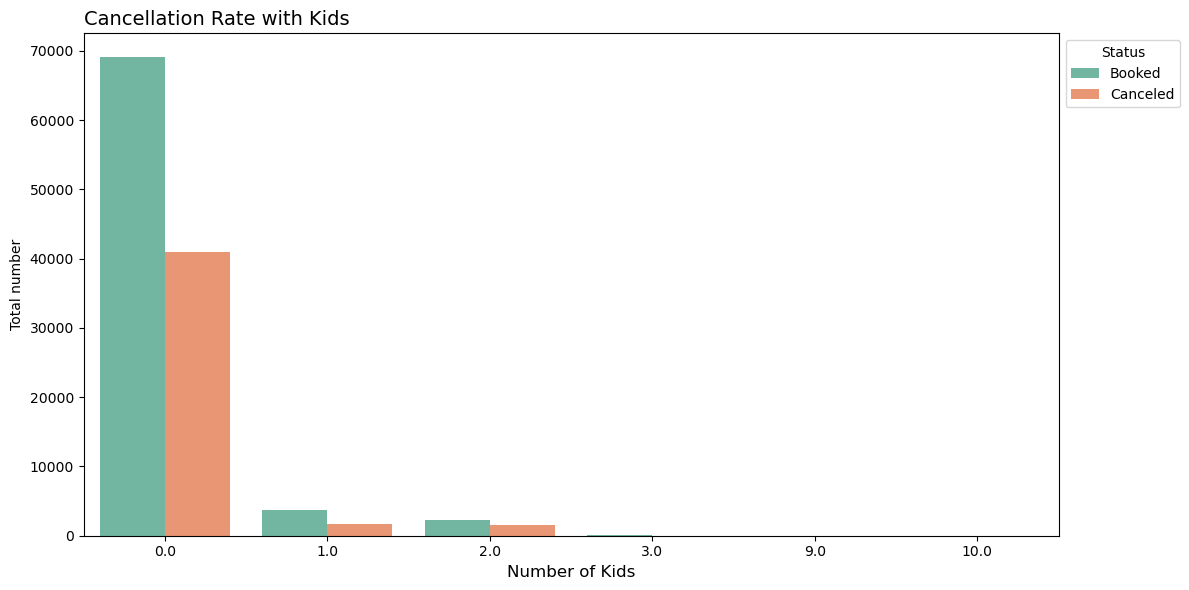

In [230]:
# Question: Does bookings with children have a higher cancellation rate? 
# Creating new column 'kids' and accumulate children + babies
df['kids'] = df['children'] + df['babies']

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='kids', hue='is_canceled', palette='Set2')
plt.title('Cancellation Rate with Kids', fontsize=14, loc='left')
plt.xlabel('Number of Kids', fontsize=12)
plt.ylabel('Total number')
plt.legend(bbox_to_anchor=(1,1), loc='upper left', title='Status', labels=['Booked', 'Canceled'])

plt.tight_layout()
plt.show()

In [223]:
df.groupby('kids')['is_canceled'].mean()*100

kids
0.0     37.219002
1.0     30.793243
2.0     41.118770
3.0     27.027027
9.0      0.000000
10.0    50.000000
Name: is_canceled, dtype: float64

In [224]:
df.groupby('kids')['is_canceled'].sum()

kids
0.0     40961
1.0      1677
2.0      1551
3.0        30
9.0         0
10.0        1
Name: is_canceled, dtype: int64

### Analysis: Cancellations with Kids
* **Initial Observation (Absolute Numbers):** The count plot suggests that the vast majority of cancellations come from guests traveling without children. 
* **Deep Dive (Relative Rates):** However, calculating the actual cancellation rates via `.groupby()` reveals a slightly different story. While guests without kids have a cancellation rate of **37.1%**, bookings with **2 kids** show a higher relative cancellation rate of **41.9%**.
* **Business & Volume Impact:** Although the relative cancellation rate for bookings with 2 children is the highest, their absolute number of bookings is extremely low. This segment is statistically interesting but financially negligible for the hotel's overall performance.
* **Strategic Recommendation:** Due to the massive volume of the customer segment traveling without children, hotel management should heavily focus restrictive measures—such as non-refundable rates, stricter cancellation policies, or upfront deposits—primarily on guests traveling without kids. This is where the hotel has the largest lever to effectively mitigate revenue loss. 
*(Note: The 100% cancellation rate for 9 kids is a clear data anomaly, likely representing a single canceled group booking).*

In [225]:
# Questions: Is there a special time of the year of a higher cancellation rate?
# Groupby Month and calcualte the mean of the cancellations
df.groupby(['hotel', 'arrival_date_month'])['is_canceled'].mean()*100

hotel         arrival_date_month
City Hotel    April                 46.323529
              August                40.097963
              December              42.110358
              February              38.288016
              January               39.668094
              July                  40.875371
              June                  44.692171
              March                 36.946423
              May                   44.375607
              November              38.122561
              October               42.971729
              September             42.027027
Resort Hotel  April                 29.343308
              August                33.449121
              December              23.829305
              February              25.620367
              January               14.819881
              July                  31.401706
              June                  33.070608
              March                 22.871703
              May                   28.772127
 

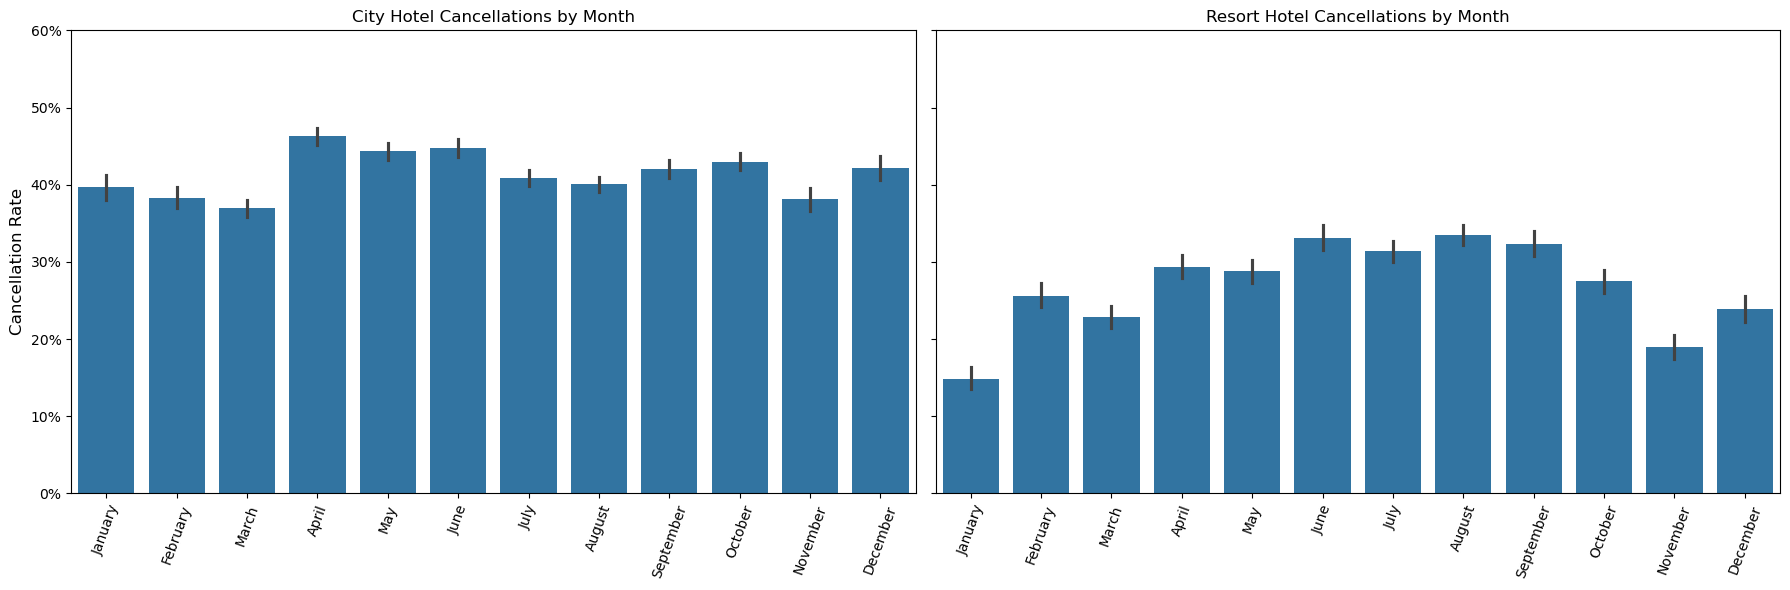

In [ ]:
# Setting a months order instead of a-z
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
city_hotel_df = df[df['hotel'] == 'City Hotel']
resort_hotel_df =df[df['hotel'] == 'Resort Hotel']

fig, axes = plt.subplots(1, 2, figsize=(18,6), sharey=True)
sns.barplot(data=city_hotel_df, x='arrival_date_month', y='is_canceled', order=months, ax=axes[0])
axes[0].set_xlabel('')
axes[0].set_title('City Hotel Cancellations by Month', fontsize=12)
axes[0].tick_params(axis='x', rotation=70)

axes[0].set_ylabel('Cancellation Rate', fontsize=12)
axes[0].set_ylim(0.0, 0.6)
axes[0].set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
axes[0].set_yticklabels(['0%', '10%', '20%', '30%', '40%', '50%', '60%'])

sns.barplot(data=resort_hotel_df, x='arrival_date_month', y='is_canceled', order=months, ax=axes[1])
axes[1].set_xlabel('')
axes[1].set_title('Resort Hotel Cancellations by Month', fontsize=12)
axes[1].tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.show()


### Analysis: Cancellation Distribution by Month & Hotel
* **City Hotel (Structural Risk):** The chart reveals an alarming trend for the City Hotel, where the cancellation rate hovers consistently around **40% almost every single month**, regardless of the season. This indicates a deep structural issue—likely driven by business travelers or short-notice online bookings. Immediate operational actions, such as introducing non-refundable base rates or mandatory credit card pre-authorization, are required.
* **Resort Hotel (Seasonal Risk):** In contrast, the Resort Hotel shows a much healthier, classic seasonal distribution. Cancellations peak significantly during the **summer months (June, July, August, September), reaching up to 30%**. This reflects the volatile nature of holiday bookings, which are planned long in advance. 
* **Strategic Recommendation:** While the City Hotel needs a year-round, strict cancellation policy, the Resort Hotel should implement **dynamic seasonal restrictions**. For instance, during the high-season summer months, the hotel should enforce stricter deposit requirements (e.g., a 20% non-refundable deposit) to secure revenue against late cancellations.

In [228]:
# Question: Does restricted rates are also been cancelled in advance
df.groupby('deposit_type')['is_canceled'].value_counts()

deposit_type  is_canceled
No Deposit    0              74947
              1              29694
Non Refund    1              14494
              0                 93
Refundable    0                126
              1                 36
Name: count, dtype: int64

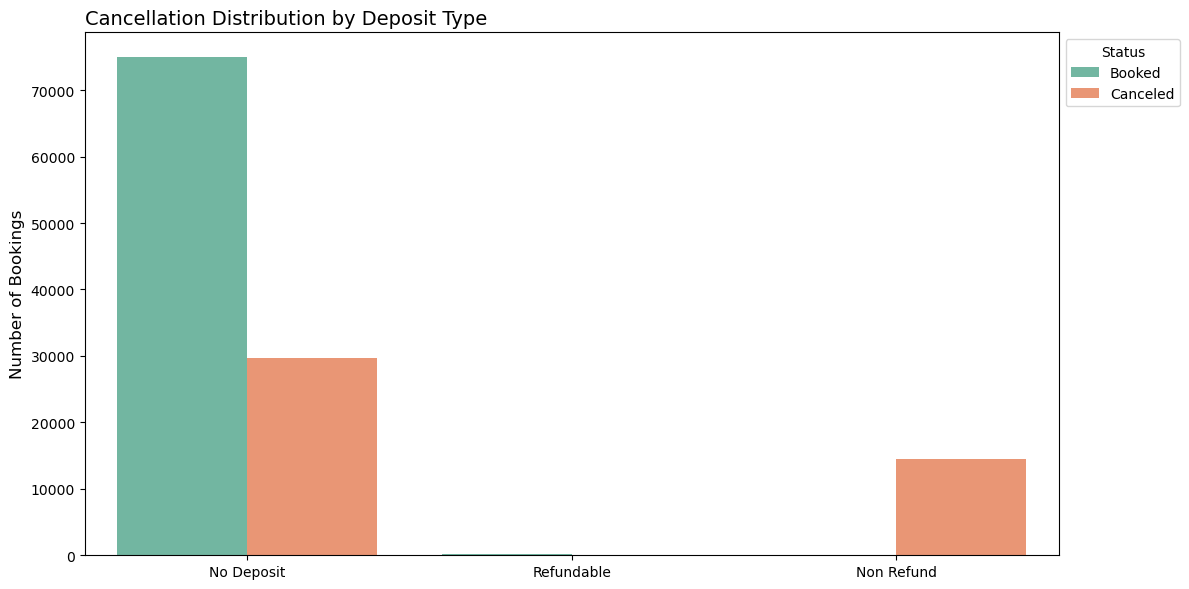

In [233]:
# Visualize the deposit type and cancellation distribution
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='deposit_type', hue='is_canceled', palette='Set2')
plt.title('Cancellation Distribution by Deposit Type', fontsize=14, loc='left')
plt.xlabel('')
plt.ylabel('Number of Bookings', fontsize=12)
plt.legend(bbox_to_anchor=(1,1), loc='upper left', title='Status', labels=['Booked', 'Canceled'])

plt.tight_layout()
plt.show()

### Analysis : Cancellation Distribution by Deposit Type
* **The Non-Refundable Paradox:** The chart reveals a massive, counter-intuitive anomaly: bookings with a **"Non Refund" policy have a cancellation rate of nearly 99%** (where `is_canceled = 1`). Intuitively, guests paying upfront without a refund option should be the least likely to cancel. This indicates a systemic issue—potentially driven by large travel agency group bookings (wholesalers blocking and dropping contingencies) or credit card fraud/chargeback patterns.
* **The Irrelevance of Refundable Rates:** "Refundable" deposits are practically non-existent in the dataset. Since this rate type generates neither significant bookings nor predictable revenue, hotel management should consider **deactivating this option entirely** to simplify the tariff structure and streamline distribution channels.
* **Main Business Volume:** The vast majority of bookings are made under the **"No Deposit"** policy. This is the hotel's main volume driver, showing a standard, expected cancellation split.

* **Strategic Recommendation:** 
  1. **Audit Distribution Channels:** Management must immediately audit which specific booking platforms or market segments the "Non Refund" bookings originate from. 
  2. **Fraud Prevention:** Implement stricter automated credit card pre-authorization and fraud checks at the time of booking to reduce malicious or volatile automated bookings.
  3. **Financial Investigation:** Further investigate if the "Non-Refundable" fees were actually collected by accounting or if these represent unrecovered revenue losses (e.g., due to successful chargebacks).

In [245]:
# Checking which hotel does have more 'non-refund' rate which are canceled
df.groupby(['hotel', 'is_canceled'])['deposit_type'].value_counts()

hotel         is_canceled  deposit_type
City Hotel    0            No Deposit      46198
                           Non Refund         24
                           Refundable          6
              1            No Deposit      20244
                           Non Refund      12844
                           Refundable         14
Resort Hotel  0            No Deposit      28749
                           Refundable        120
                           Non Refund         69
              1            No Deposit       9450
                           Non Refund       1650
                           Refundable         22
Name: count, dtype: int64